# Deep Analysis: Protein Families Unique to Kmerseek HP

This notebook investigates the ~88 protein families that Kmerseek HP (k=35/k=36 with TF-IDF > 1000) successfully detects but **neither** FoldSeek **nor** TEA find.

## Goals
1. Identify and characterize these unique families
2. Analyze their SCOPe structural classification (class, fold, superfamily)
3. Examine sequence properties (length, composition)
4. Investigate why structure-based methods (FoldSeek/TEA) might miss these
5. Look for patterns that make HP-encoding particularly effective

In [32]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import sys

# Add notebooks directory to path for imports
sys.path.append(str(Path.cwd()))
from scope_kmerseek_utils import (
    read_csv_with_size_limit,
    load_rocx_file,
    kmerseek_to_rocx,
    compute_auc,
    plot_sensitivity_from_rocx,
)

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

## 1. Load Data

In [33]:
# Data paths
data_dir = Path("/Users/olga/data/scope/results-2025-12-25-average_kmer_rarity")
tea_dir = Path("/Users/olga/code/2024-kmerseek-analysis/data/tea_scope40_rocx_files")

# Load HP k=35 and k=36 results
hp_k35_path = (
    data_dir
    / "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k35.scaled1.kmerseek.results.csv"
)
hp_k36_path = (
    data_dir
    / "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k36.scaled1.kmerseek.results.csv"
)

hp_k35_raw = read_csv_with_size_limit(hp_k35_path)
hp_k36_raw = read_csv_with_size_limit(hp_k36_path)

print(f"HP k=35 raw shape: {hp_k35_raw.shape}")
print(f"HP k=36 raw shape: {hp_k36_raw.shape}")

Loading astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k35.scaled1.kmerseek.results.csv (0.00 GB) - reading all rows...
Loading astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k36.scaled1.kmerseek.results.csv (0.00 GB) - reading all rows...
HP k=35 raw shape: (354, 30)
HP k=36 raw shape: (243, 30)


In [34]:
# Filter to TF-IDF > 1000 (the threshold that gives good performance)
hp_k35 = hp_k35_raw.filter(pl.col("tfidf") > 1000)
hp_k36 = hp_k36_raw.filter(pl.col("tfidf") > 1000)

print(f"HP k=35 with TF-IDF > 1000: {hp_k35.shape[0]:,} rows")
print(f"HP k=36 with TF-IDF > 1000: {hp_k36.shape[0]:,} rows")

HP k=35 with TF-IDF > 1000: 227 rows
HP k=36 with TF-IDF > 1000: 140 rows


In [35]:
# Load FoldSeek and TEA benchmark data
foldseek = load_rocx_file(tea_dir / "foldseek.rocx")
print(f"FoldSeek: {len(foldseek)} queries")

tea_all = pl.read_csv(tea_dir / "tea_all.rocx", separator=",")
print(f"TEA: {len(tea_all)} queries")

FoldSeek: 5713 queries
TEA: 5737 queries


In [36]:
tea_all.head()

NAME,SCOP,FAM,SFAM,FOLD,FP,FAMCNT,SFAMCNT,FOLDCNT
str,str,f64,f64,f64,i64,i64,i64,i64
"""d1b9ha_""","""c.67.1.4""",1.0,0.992366,0.0,1,13,143,145
"""d3ctaa2""","""b.43.5.2""",0.0,0.0,0.0,1,2,6,55
"""d2ckxa1""","""a.4.1.3""",0.928571,0.222222,0.003195,1,15,113,425
"""d5r4oa_""","""a.29.2.0""",1.0,0.6,0.0,1,27,31,73
"""d1w5sa1""","""a.4.5.11""",1.0,0.662651,0.0977011,1,4,252,425


In [37]:
# Convert HP results to ROCX format for comparison
hp_k35_rocx = kmerseek_to_rocx(hp_k35, score_col="tfidf", overlap_threshold=0.0)
hp_k36_rocx = kmerseek_to_rocx(hp_k36, score_col="tfidf", overlap_threshold=0.0)

print(f"HP k=35 ROCX: {len(hp_k35_rocx)} queries")
print(f"HP k=36 ROCX: {len(hp_k36_rocx)} queries")

HP k=35 ROCX: 212 queries
HP k=36 ROCX: 128 queries


In [38]:
hp_k35_rocx.head()

NAME,SCOP,FAM,FAMCNT,SFAM,SFAMCNT,FOLD,FOLDCNT,FP
str,str,f64,i64,f64,i64,f64,i64,i64
"""d1r9da_""","""c.7.1.1""",0.0,0,1.0,2,1.0,2,1
"""g1qhh.1""","""c.37.1.19""",0.0,0,1.0,2,1.0,2,1
"""d3i4fa_""","""c.2.1.0""",1.0,3,1.0,3,1.0,3,0
"""d1wqga_""","""d.67.3.1""",1.0,2,1.0,2,1.0,2,0
"""d6l25a1""","""c.1.9.0""",0.0,0,0.0,0,0.0,0,1


## 2. Identify Unique Families at 40% Threshold

In [39]:
# Load SCOPe 40% threshold data to filter families
scope_th40_path = Path(
    "/Users/olga/code/2024-kmerseek-analysis/data/SCOPe/processed_at_th/th_40.tsv"
)
scope_th40 = pl.read_csv(scope_th40_path, separator="\t")
print(f"SCOPe 40% threshold: {len(scope_th40)} domains")

# Get families at 40% threshold
scope_fams_at_40 = set(scope_th40["family"].unique().to_list())
print(f"Families at 40% threshold: {len(scope_fams_at_40)}")

SCOPe 40% threshold: 14280 domains
Families at 40% threshold: 4521


In [40]:
list(scope_fams_at_40)[:10]

['g.31.1.2',
 'c.108.1.1',
 'd.79.3.1',
 'd.58.3.1',
 'g.2.1.1',
 'c.10.2.7',
 'b.40.12.1',
 'f.23.11.1',
 'g.6.1.1',
 'a.140.3.2']

In [41]:
# Extract families from each method
# HP uses SCOP column for full family classification (e.g., 'a.1.1.1')
hp_k35_fams = set(hp_k35_rocx["SCOP"].unique().to_list())
hp_k36_fams = set(hp_k36_rocx["SCOP"].unique().to_list())
hp_combined_fams = hp_k35_fams | hp_k36_fams

# FoldSeek and TEA use SCOP column
foldseek_fams = set(foldseek["SCOP"].unique().to_list())
tea_fams = set(tea_all["SCOP"].unique().to_list())

print(f"HP k=35 families: {len(hp_k35_fams)}")
print(f"HP k=36 families: {len(hp_k36_fams)}")
print(f"HP combined families: {len(hp_combined_fams)}")
print(f"FoldSeek families: {len(foldseek_fams)}")
print(f"TEA families: {len(tea_fams)}")

HP k=35 families: 136
HP k=36 families: 80
HP combined families: 136
FoldSeek families: 943
TEA families: 950


In [42]:
hp_k35_fams & foldseek_fams

{'a.102.1.0',
 'a.118.1.2',
 'a.25.1.1',
 'a.39.1.5',
 'a.4.5.0',
 'b.1.1.0',
 'b.1.1.1',
 'b.52.1.0',
 'b.82.2.0',
 'b.82.2.1',
 'b.84.3.1',
 'c.1.10.0',
 'c.1.11.0',
 'c.1.12.0',
 'c.1.2.1',
 'c.1.4.1',
 'c.1.8.0',
 'c.1.8.3',
 'c.1.9.0',
 'c.23.1.0',
 'c.23.5.0',
 'c.26.1.0',
 'c.26.1.1',
 'c.26.1.3',
 'c.44.3.0',
 'c.55.3.15',
 'c.67.1.0',
 'c.67.1.4',
 'c.72.1.0',
 'c.72.1.1',
 'c.78.1.0',
 'c.92.2.2',
 'c.92.2.3',
 'c.92.2.4',
 'c.97.1.2',
 'd.58.26.0',
 'd.58.31.0',
 'd.58.31.2',
 'd.81.1.1',
 'd.92.1.7',
 'f.4.3.0',
 'f.4.7.0'}

In [43]:
list(foldseek_fams)[:10]

['b.34.10.1',
 'd.79.3.1',
 'd.58.3.1',
 'b.82.2.10',
 'a.25.3.0',
 'c.26.1.0',
 'c.10.2.7',
 'a.140.3.2',
 'd.74.3.2',
 'c.72.1.2']

In [44]:
# Filter to families at 40% threshold
hp_at_40 = hp_combined_fams & scope_fams_at_40
fs_at_40 = foldseek_fams & scope_fams_at_40
tea_at_40 = tea_fams & scope_fams_at_40

print(f"\nFamilies at 40% threshold:")
print(f"  HP: {len(hp_at_40)}")
print(f"  FoldSeek: {len(fs_at_40)}")
print(f"  TEA: {len(tea_at_40)}")


Families at 40% threshold:
  HP: 130
  FoldSeek: 915
  TEA: 920


In [45]:
# Find families UNIQUE to HP (not in FoldSeek OR TEA)
hp_unique_fams = hp_at_40 - (fs_at_40 | tea_at_40)
hp_not_foldseek = hp_at_40 - fs_at_40
hp_not_tea = hp_at_40 - tea_at_40

print(f"\n" + "=" * 70)
print(f"HP UNIQUE FAMILIES AT 40% THRESHOLD")
print(f"=" * 70)
print(f"Total HP families at 40%: {len(hp_at_40)}")
print(
    f"HP finds but FoldSeek doesn't: {len(hp_not_foldseek)} ({len(hp_not_foldseek)/len(hp_at_40)*100:.1f}%)"
)
print(
    f"HP finds but TEA doesn't: {len(hp_not_tea)} ({len(hp_not_tea)/len(hp_at_40)*100:.1f}%)"
)
print(
    f"\nHP UNIQUE (not in FoldSeek OR TEA): {len(hp_unique_fams)} ({len(hp_unique_fams)/len(hp_at_40)*100:.1f}%)"
)


HP UNIQUE FAMILIES AT 40% THRESHOLD
Total HP families at 40%: 130
HP finds but FoldSeek doesn't: 88 (67.7%)
HP finds but TEA doesn't: 88 (67.7%)

HP UNIQUE (not in FoldSeek OR TEA): 88 (67.7%)


## 3. SCOPe Classification Analysis

What structural classes do these unique families belong to?

In [46]:
# Parse SCOPe classifications
def parse_scop(scop_str):
    """Parse SCOPe classification string like 'a.1.2.3' into components."""
    parts = scop_str.split(".")
    return {
        "class": parts[0] if len(parts) > 0 else None,
        "fold": ".".join(parts[:2]) if len(parts) > 1 else None,
        "superfamily": ".".join(parts[:3]) if len(parts) > 2 else None,
        "family": scop_str,
    }


# SCOPe class descriptions
SCOP_CLASS_NAMES = {
    "a": "All alpha proteins",
    "b": "All beta proteins",
    "c": "Alpha and beta proteins (a/b)",
    "d": "Alpha and beta proteins (a+b)",
    "e": "Multi-domain proteins",
    "f": "Membrane and cell surface proteins",
    "g": "Small proteins",
    "h": "Coiled coil proteins",
    "i": "Low resolution protein structures",
    "j": "Peptides",
    "k": "Designed proteins",
}

# Parse unique families
unique_fam_data = []
for fam in hp_unique_fams:
    parsed = parse_scop(fam)
    unique_fam_data.append(
        {
            "family": fam,
            "scop_class": parsed["class"],
            "scop_fold": parsed["fold"],
            "scop_superfamily": parsed["superfamily"],
        }
    )

unique_fams_df = pl.DataFrame(unique_fam_data)
print(f"Parsed {len(unique_fams_df)} unique families")
unique_fams_df.head(10)

Parsed 88 unique families


family,scop_class,scop_fold,scop_superfamily
str,str,str,str
"""c.87.1.0""","""c""","""c.87""","""c.87.1"""
"""f.13.1.0""","""f""","""f.13""","""f.13.1"""
"""c.7.1.0""","""c""","""c.7""","""c.7.1"""
"""d.67.3.1""","""d""","""d.67""","""d.67.3"""
"""c.121.1.0""","""c""","""c.121""","""c.121.1"""
"""c.82.1.2""","""c""","""c.82""","""c.82.1"""
"""c.7.1.1""","""c""","""c.7""","""c.7.1"""
"""c.94.1.0""","""c""","""c.94""","""c.94.1"""
"""c.47.1.19""","""c""","""c.47""","""c.47.1"""


In [47]:
# Count by SCOPe class
class_counts = (
    unique_fams_df.group_by("scop_class")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
)
print("\nDistribution by SCOPe class:")
print(class_counts)

print("\nClass descriptions:")
for row in class_counts.iter_rows(named=True):
    cls = row["scop_class"]
    desc = SCOP_CLASS_NAMES.get(cls, "Unknown")
    pct = row["count"] / len(unique_fams_df) * 100
    print(f"  {cls}: {row['count']:3d} ({pct:5.1f}%) - {desc}")


Distribution by SCOPe class:
shape: (6, 2)
┌────────────┬───────┐
│ scop_class ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ c          ┆ 38    │
│ d          ┆ 16    │
│ a          ┆ 15    │
│ f          ┆ 9     │
│ e          ┆ 6     │
│ b          ┆ 4     │
└────────────┴───────┘

Class descriptions:
  c:  38 ( 43.2%) - Alpha and beta proteins (a/b)
  d:  16 ( 18.2%) - Alpha and beta proteins (a+b)
  a:  15 ( 17.0%) - All alpha proteins
  f:   9 ( 10.2%) - Membrane and cell surface proteins
  e:   6 (  6.8%) - Multi-domain proteins
  b:   4 (  4.5%) - All beta proteins


In [48]:
# Compare class distribution: HP-unique vs all HP vs FoldSeek vs TEA
def get_class_distribution(families):
    """Get class distribution from a set of families."""
    classes = [parse_scop(f)["class"] for f in families]
    return Counter(classes)


hp_unique_classes = get_class_distribution(hp_unique_fams)
hp_all_classes = get_class_distribution(hp_at_40)
fs_classes = get_class_distribution(fs_at_40)
tea_classes = get_class_distribution(tea_at_40)

# Build comparison dataframe
all_classes = sorted(
    set(hp_unique_classes.keys())
    | set(hp_all_classes.keys())
    | set(fs_classes.keys())
    | set(tea_classes.keys())
)

class_comparison = []
for cls in all_classes:
    class_comparison.append(
        {
            "class": cls,
            "class_name": SCOP_CLASS_NAMES.get(cls, "Unknown"),
            "HP_unique": hp_unique_classes.get(cls, 0),
            "HP_all": hp_all_classes.get(cls, 0),
            "FoldSeek": fs_classes.get(cls, 0),
            "TEA": tea_classes.get(cls, 0),
        }
    )

class_comp_df = pl.DataFrame(class_comparison).sort("HP_unique", descending=True)
print("\nClass distribution comparison:")
print(class_comp_df)


Class distribution comparison:
shape: (7, 6)
┌───────┬─────────────────────────────────┬───────────┬────────┬──────────┬─────┐
│ class ┆ class_name                      ┆ HP_unique ┆ HP_all ┆ FoldSeek ┆ TEA │
│ ---   ┆ ---                             ┆ ---       ┆ ---    ┆ ---      ┆ --- │
│ str   ┆ str                             ┆ i64       ┆ i64    ┆ i64      ┆ i64 │
╞═══════╪═════════════════════════════════╪═══════════╪════════╪══════════╪═════╡
│ c     ┆ Alpha and beta proteins (a/b)   ┆ 38        ┆ 62     ┆ 216      ┆ 217 │
│ d     ┆ Alpha and beta proteins (a+b)   ┆ 16        ┆ 21     ┆ 216      ┆ 217 │
│ a     ┆ All alpha proteins              ┆ 15        ┆ 20     ┆ 176      ┆ 177 │
│ f     ┆ Membrane and cell surface prot… ┆ 9         ┆ 11     ┆ 20       ┆ 20  │
│ e     ┆ Multi-domain proteins           ┆ 6         ┆ 6      ┆ 0        ┆ 0   │
│ b     ┆ All beta proteins               ┆ 4         ┆ 10     ┆ 256      ┆ 258 │
│ g     ┆ Small proteins                  ┆ 0       

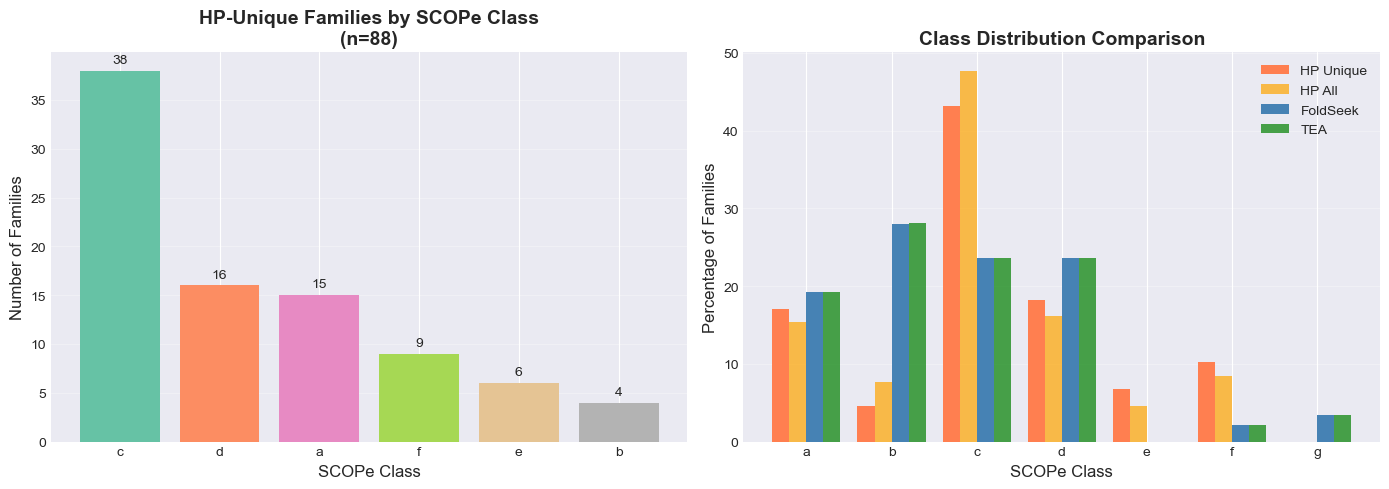

In [49]:
# Visualize class distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: HP-unique class distribution
ax = axes[0]
colors = plt.cm.Set2(np.linspace(0, 1, len(class_counts)))
bars = ax.bar(
    class_counts["scop_class"].to_list(), class_counts["count"].to_list(), color=colors
)
ax.set_xlabel("SCOPe Class", fontsize=12)
ax.set_ylabel("Number of Families", fontsize=12)
ax.set_title(
    f"HP-Unique Families by SCOPe Class\n(n={len(hp_unique_fams)})",
    fontsize=14,
    fontweight="bold",
)
ax.grid(True, alpha=0.3, axis="y")

# Add value labels on bars
for bar, val in zip(bars, class_counts["count"].to_list()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(val),
        ha="center",
        va="bottom",
        fontsize=10,
    )

# Plot 2: Comparison across methods (normalized)
ax = axes[1]
x = np.arange(len(all_classes))
width = 0.2

# Normalize to percentages
hp_unique_pct = [
    hp_unique_classes.get(c, 0) / len(hp_unique_fams) * 100 for c in all_classes
]
hp_all_pct = [hp_all_classes.get(c, 0) / len(hp_at_40) * 100 for c in all_classes]
fs_pct = [fs_classes.get(c, 0) / len(fs_at_40) * 100 for c in all_classes]
tea_pct = [tea_classes.get(c, 0) / len(tea_at_40) * 100 for c in all_classes]

ax.bar(x - 1.5 * width, hp_unique_pct, width, label="HP Unique", color="coral")
ax.bar(x - 0.5 * width, hp_all_pct, width, label="HP All", color="orange", alpha=0.7)
ax.bar(x + 0.5 * width, fs_pct, width, label="FoldSeek", color="steelblue")
ax.bar(x + 1.5 * width, tea_pct, width, label="TEA", color="green", alpha=0.7)

ax.set_xlabel("SCOPe Class", fontsize=12)
ax.set_ylabel("Percentage of Families", fontsize=12)
ax.set_title("Class Distribution Comparison", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(all_classes)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(
    "hp_unique_families_scop_class_distribution.pdf", bbox_inches="tight", dpi=300
)
plt.show()

## 4. Superfamily Analysis

Which superfamilies contain HP-unique families?

In [50]:
# Count by superfamily
sfam_counts = (
    unique_fams_df.group_by("scop_superfamily")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
)
print(f"\nUnique families span {len(sfam_counts)} superfamilies")
print(f"\nTop 20 superfamilies with HP-unique families:")
print(sfam_counts.head(20))


Unique families span 68 superfamilies

Top 20 superfamilies with HP-unique families:
shape: (20, 2)
┌──────────────────┬───────┐
│ scop_superfamily ┆ count │
│ ---              ┆ ---   │
│ str              ┆ u32   │
╞══════════════════╪═══════╡
│ c.37.1           ┆ 5     │
│ c.69.1           ┆ 4     │
│ d.219.1          ┆ 2     │
│ c.82.1           ┆ 2     │
│ e.1.1            ┆ 2     │
│ …                ┆ …     │
│ d.20.1           ┆ 1     │
│ c.80.1           ┆ 1     │
│ a.104.1          ┆ 1     │
│ c.146.1          ┆ 1     │
│ c.47.1           ┆ 1     │
└──────────────────┴───────┘


In [51]:
# For each unique family, get query counts from HP
family_query_data = []
for fam in hp_unique_fams:
    n_k35 = len(hp_k35_rocx.filter(pl.col("SCOP") == fam))
    n_k36 = len(hp_k36_rocx.filter(pl.col("SCOP") == fam))
    parsed = parse_scop(fam)

    family_query_data.append(
        {
            "family": fam,
            "superfamily": parsed["superfamily"],
            "scop_class": parsed["class"],
            "n_queries_k35": n_k35,
            "n_queries_k36": n_k36,
            "n_queries_total": n_k35 + n_k36,
        }
    )

family_queries_df = pl.DataFrame(family_query_data).sort(
    "n_queries_total", descending=True
)
print("\nHP-unique families with query counts:")
print(family_queries_df.head(20))


HP-unique families with query counts:
shape: (20, 6)
┌───────────┬─────────────┬────────────┬───────────────┬───────────────┬─────────────────┐
│ family    ┆ superfamily ┆ scop_class ┆ n_queries_k35 ┆ n_queries_k36 ┆ n_queries_total │
│ ---       ┆ ---         ┆ ---        ┆ ---           ┆ ---           ┆ ---             │
│ str       ┆ str         ┆ str        ┆ i64           ┆ i64           ┆ i64             │
╞═══════════╪═════════════╪════════════╪═══════════════╪═══════════════╪═════════════════╡
│ d.144.1.0 ┆ d.144.1     ┆ d          ┆ 8             ┆ 4             ┆ 12              │
│ c.37.1.0  ┆ c.37.1      ┆ c          ┆ 6             ┆ 4             ┆ 10              │
│ a.104.1.0 ┆ a.104.1     ┆ a          ┆ 5             ┆ 4             ┆ 9               │
│ d.144.1.7 ┆ d.144.1     ┆ d          ┆ 4             ┆ 4             ┆ 8               │
│ f.13.1.0  ┆ f.13.1      ┆ f          ┆ 3             ┆ 3             ┆ 6               │
│ …         ┆ …           ┆ …       

In [52]:
# Summary statistics
print("\nQuery count statistics for HP-unique families:")
print(f"  Mean queries per family: {family_queries_df['n_queries_total'].mean():.1f}")
print(
    f"  Median queries per family: {family_queries_df['n_queries_total'].median():.1f}"
)
print(f"  Min: {family_queries_df['n_queries_total'].min()}")
print(f"  Max: {family_queries_df['n_queries_total'].max()}")

# Distribution of query counts
print(
    f"\nFamilies with only 1-2 queries: {len(family_queries_df.filter(pl.col('n_queries_total') <= 2))}"
)
print(
    f"Families with 3-5 queries: {len(family_queries_df.filter((pl.col('n_queries_total') > 2) & (pl.col('n_queries_total') <= 5)))}"
)
print(
    f"Families with >5 queries: {len(family_queries_df.filter(pl.col('n_queries_total') > 5))}"
)


Query count statistics for HP-unique families:
  Mean queries per family: 2.5
  Median queries per family: 2.0
  Min: 1
  Max: 12

Families with only 1-2 queries: 63
Families with 3-5 queries: 18
Families with >5 queries: 7


## 5. Detailed Look at HP-Unique Families

Let's examine the specific families and queries.

In [53]:
# Get details for each unique family's queries
def get_family_queries(fam, hp_k35_rocx, hp_k36_rocx):
    """Get all queries for a family from both k sizes."""
    k35_queries = hp_k35_rocx.filter(pl.col("SCOP") == fam)
    k36_queries = hp_k36_rocx.filter(pl.col("SCOP") == fam)
    return k35_queries, k36_queries


# Show top families with most queries
print("\nDetailed view of HP-unique families with most queries:")
print("=" * 80)

for row in family_queries_df.head(15).iter_rows(named=True):
    fam = row["family"]
    k35_q, k36_q = get_family_queries(fam, hp_k35_rocx, hp_k36_rocx)

    print(f"\n{fam} (class={row['scop_class']}, superfamily={row['superfamily']})")
    print(f"  k=35 queries: {len(k35_q)}, k=36 queries: {len(k36_q)}")

    # Show query names and sensitivity
    all_queries = pl.concat([k35_q, k36_q]).unique(subset=["NAME"])
    for qrow in all_queries.iter_rows(named=True):
        sfam_sens = qrow.get("SFAM", "N/A")
        sfamcnt = qrow.get("SFAMCNT", "N/A")
        print(f"    {qrow['NAME']}: SFAM={sfam_sens}, SFAMCNT={sfamcnt}")


Detailed view of HP-unique families with most queries:

d.144.1.0 (class=d, superfamily=d.144.1)
  k=35 queries: 8, k=36 queries: 4
    d4b9da1: SFAM=1.0, SFAMCNT=2
    d6ctha1: SFAM=1.0, SFAMCNT=2
    d6n7aa_: SFAM=1.0, SFAMCNT=2
    d2wqma_: SFAM=1.0, SFAMCNT=2
    d2weia1: SFAM=1.0, SFAMCNT=3
    d2wtkc1: SFAM=1.0, SFAMCNT=2
    d4b6la_: SFAM=1.0, SFAMCNT=2
    d4nfna_: SFAM=0.0, SFAMCNT=0

c.37.1.0 (class=c, superfamily=c.37.1)
  k=35 queries: 6, k=36 queries: 4
    d2lkca1: SFAM=0.0, SFAMCNT=0
    d2z0ma2: SFAM=1.0, SFAMCNT=2
    d3lfua2: SFAM=1.0, SFAMCNT=2
    d2yjtd_: SFAM=1.0, SFAMCNT=2
    d6id0c1: SFAM=1.0, SFAMCNT=2
    d6ui4a_: SFAM=1.0, SFAMCNT=2

a.104.1.0 (class=a, superfamily=a.104.1)
  k=35 queries: 5, k=36 queries: 4
    d3r9ba_: SFAM=1.0, SFAMCNT=2
    d5li7a_: SFAM=0.0, SFAMCNT=0
    d4yzra_: SFAM=1.0, SFAMCNT=2
    d2z3ta_: SFAM=1.0, SFAMCNT=2
    d4pxha_: SFAM=1.0, SFAMCNT=2

d.144.1.7 (class=d, superfamily=d.144.1)
  k=35 queries: 4, k=36 queries: 4
    d6yoja_

## 6. SCOPe Annotations for Unique Families

Get descriptions and characteristics from SCOPe annotations.

In [54]:
# Use the already-loaded scope_th40 data for annotations
# scope_th40 contains: sid, span, sccs, cls_label, fold, superfamily, family, seq, description, seq_len
print(f"Using SCOPe 40% threshold data for annotations: {len(scope_th40)} domains")
print(f"Columns available: {scope_th40.columns}")
print(scope_th40.head())

Using SCOPe 40% threshold data for annotations: 14280 domains
Columns available: ['sid', 'span', 'sccs', 'cls_label', 'fold', 'superfamily', 'family', 'seq', 'description', 'seq_len']
shape: (5, 10)
┌─────────┬──────┬─────────┬───────────┬───┬─────────┬─────────────────┬─────────────────┬─────────┐
│ sid     ┆ span ┆ sccs    ┆ cls_label ┆ … ┆ family  ┆ seq             ┆ description     ┆ seq_len │
│ ---     ┆ ---  ┆ ---     ┆ ---       ┆   ┆ ---     ┆ ---             ┆ ---             ┆ ---     │
│ str     ┆ str  ┆ str     ┆ str       ┆   ┆ str     ┆ str             ┆ str             ┆ i64     │
╞═════════╪══════╪═════════╪═══════════╪═══╪═════════╪═════════════════╪═════════════════╪═════════╡
│ d1dlwa_ ┆ (A:) ┆ a.1.1.1 ┆ a         ┆ … ┆ a.1.1.1 ┆ SLFEQLGGQAAVQAV ┆ Protozoan/bacte ┆ 116     │
│         ┆      ┆         ┆           ┆   ┆         ┆ TAQFYANIQADATVA ┆ rial            ┆         │
│         ┆      ┆         ┆           ┆   ┆         ┆ …               ┆ hemoglobin…     ┆    

In [55]:
# Get descriptions for unique families from scope_th40
unique_fam_descriptions = (
    scope_th40.filter(pl.col("family").is_in(list(hp_unique_fams)))
    .group_by("family")
    .agg(
        [
            pl.len().alias("n_domains_in_scope"),
            pl.col("seq_len").mean().alias("avg_seq_len"),
            pl.col("description").first().alias("description"),
        ]
    )
    .sort("n_domains_in_scope", descending=True)
)

print(f"\nDescriptions for {len(unique_fam_descriptions)} HP-unique families:")
print(unique_fam_descriptions.head(20))


Descriptions for 88 HP-unique families:
shape: (20, 4)
┌───────────┬────────────────────┬─────────────┬─────────────────────────────────┐
│ family    ┆ n_domains_in_scope ┆ avg_seq_len ┆ description                     │
│ ---       ┆ ---                ┆ ---         ┆ ---                             │
│ str       ┆ u32                ┆ f64         ┆ str                             │
╞═══════════╪════════════════════╪═════════════╪═════════════════════════════════╡
│ c.94.1.0  ┆ 132                ┆ 305.893939  ┆ automated matches {Actinobacil… │
│ c.37.1.0  ┆ 109                ┆ 237.458716  ┆ automated matches {Acidianus h… │
│ d.144.1.0 ┆ 85                 ┆ 294.811765  ┆ automated matches {Acinetobact… │
│ c.93.1.0  ┆ 82                 ┆ 300.243902  ┆ automated matches {Actinobacil… │
│ c.69.1.0  ┆ 72                 ┆ 288.180556  ┆ automated matches {Agrobacteri… │
│ …         ┆ …                  ┆ …           ┆ …                               │
│ e.23.1.0  ┆ 21               

## 7. Why Might FoldSeek/TEA Miss These?

Investigate potential reasons why structure-based methods miss these families.

In [56]:
# Hypothesis 1: Small families (fewer members = less training data for structure comparison)
# Compare family sizes: HP-unique vs found by all methods
found_by_all = hp_at_40 & fs_at_40 & tea_at_40

hp_unique_sizes = (
    scope_th40.filter(pl.col("family").is_in(list(hp_unique_fams)))
    .group_by("family")
    .agg(pl.len().alias("n_domains"))
)

found_by_all_sizes = (
    scope_th40.filter(pl.col("family").is_in(list(found_by_all)))
    .group_by("family")
    .agg(pl.len().alias("n_domains"))
)

print("Family size comparison:")
print(f"\nHP-unique families:")
print(f"  Mean domains per family: {hp_unique_sizes['n_domains'].mean():.1f}")
print(f"  Median domains per family: {hp_unique_sizes['n_domains'].median():.1f}")

print(f"\nFamilies found by all methods:")
print(f"  Mean domains per family: {found_by_all_sizes['n_domains'].mean():.1f}")
print(f"  Median domains per family: {found_by_all_sizes['n_domains'].median():.1f}")

Family size comparison:

HP-unique families:
  Mean domains per family: 14.5
  Median domains per family: 4.5

Families found by all methods:
  Mean domains per family: 20.3
  Median domains per family: 9.0



Sequence length comparison:

HP-unique families:
  Mean seq length: 299.2
  Median seq length: 281.0

Families found by all methods:
  Mean seq length: 233.3
  Median seq length: 200.0


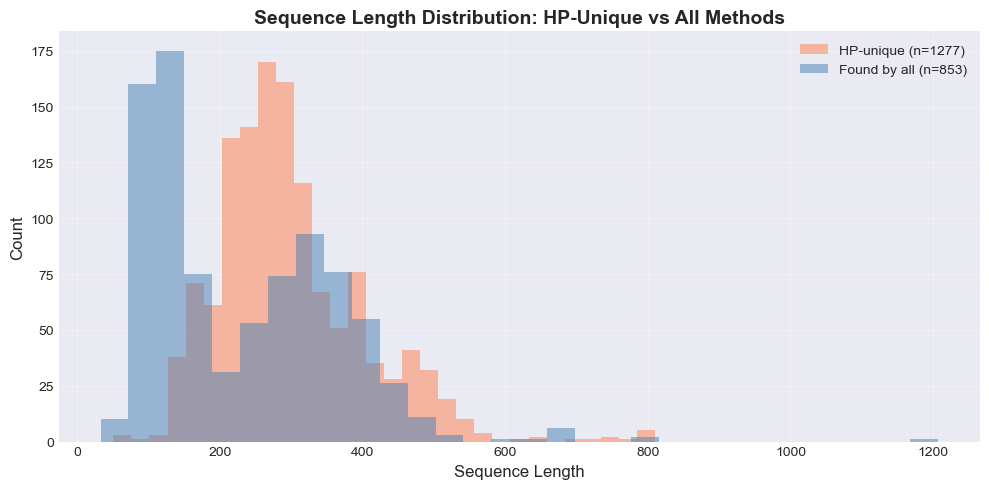

In [57]:
# Hypothesis 2: Sequence length differences
hp_unique_lens = scope_th40.filter(pl.col("family").is_in(list(hp_unique_fams)))[
    "seq_len"
]

found_by_all_lens = scope_th40.filter(pl.col("family").is_in(list(found_by_all)))[
    "seq_len"
]

print("\nSequence length comparison:")
print(f"\nHP-unique families:")
print(f"  Mean seq length: {hp_unique_lens.mean():.1f}")
print(f"  Median seq length: {hp_unique_lens.median():.1f}")

print(f"\nFamilies found by all methods:")
print(f"  Mean seq length: {found_by_all_lens.mean():.1f}")
print(f"  Median seq length: {found_by_all_lens.median():.1f}")

# Plot distributions
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    hp_unique_lens.to_numpy(),
    bins=30,
    alpha=0.5,
    label=f"HP-unique (n={len(hp_unique_lens)})",
    color="coral",
)
ax.hist(
    found_by_all_lens.to_numpy(),
    bins=30,
    alpha=0.5,
    label=f"Found by all (n={len(found_by_all_lens)})",
    color="steelblue",
)
ax.set_xlabel("Sequence Length", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title(
    "Sequence Length Distribution: HP-Unique vs All Methods",
    fontsize=14,
    fontweight="bold",
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("hp_unique_sequence_length_comparison.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [58]:
# Hypothesis 3: HP sensitivity for these families
# Check if HP is actually finding good matches (high sensitivity)
hp_unique_query_names = []
for fam in hp_unique_fams:
    k35_names = hp_k35_rocx.filter(pl.col("SCOP") == fam)["NAME"].to_list()
    k36_names = hp_k36_rocx.filter(pl.col("SCOP") == fam)["NAME"].to_list()
    hp_unique_query_names.extend(k35_names)
    hp_unique_query_names.extend(k36_names)

hp_unique_query_names = list(set(hp_unique_query_names))
print(f"Total queries from HP-unique families: {len(hp_unique_query_names)}")

# Get sensitivity for these queries
hp_unique_rocx = pl.concat(
    [
        hp_k35_rocx.filter(pl.col("NAME").is_in(hp_unique_query_names)),
        hp_k36_rocx.filter(pl.col("NAME").is_in(hp_unique_query_names)),
    ]
).unique(subset=["NAME"])

print(f"\nSensitivity statistics for HP-unique family queries:")
print(f"  Mean SFAM sensitivity: {hp_unique_rocx['SFAM'].mean():.3f}")
print(f"  Median SFAM sensitivity: {hp_unique_rocx['SFAM'].median():.3f}")
print(
    f"  Queries with perfect sensitivity (1.0): {(hp_unique_rocx['SFAM'] == 1.0).sum()}"
)

Total queries from HP-unique families: 140

Sensitivity statistics for HP-unique family queries:
  Mean SFAM sensitivity: 0.629
  Median SFAM sensitivity: 1.000
  Queries with perfect sensitivity (1.0): 88


## 8. Export Results

In [59]:
# Export HP-unique families for further analysis
family_queries_df.write_csv("hp_unique_families_at_40pct.csv")
print(
    f"Exported {len(family_queries_df)} HP-unique families to 'hp_unique_families_at_40pct.csv'"
)

# Export query-level data
hp_unique_rocx.write_csv("hp_unique_family_queries_rocx.csv")
print(f"Exported {len(hp_unique_rocx)} queries to 'hp_unique_family_queries_rocx.csv'")

Exported 88 HP-unique families to 'hp_unique_families_at_40pct.csv'
Exported 140 queries to 'hp_unique_family_queries_rocx.csv'


## 9. Summary

In [69]:
print("=" * 80)
print("SUMMARY: Protein Families Unique to Kmerseek HP")
print("=" * 80)

print(f"\n1. UNIQUE FAMILIES:")
print(f"   {len(hp_unique_fams)} families found by HP but NOT by FoldSeek or TEA")
print(
    f"   This represents {len(hp_unique_fams)/len(hp_at_40)*100:.1f}% of HP families at 40% threshold"
)

print(f"\n2. SCOPe CLASS DISTRIBUTION:")
for row in class_counts.iter_rows(named=True):
    cls = row["scop_class"]
    desc = SCOP_CLASS_NAMES.get(cls, "Unknown")
    pct = row["count"] / len(unique_fams_df) * 100
    print(f"   {cls} ({desc}): {row['count']} ({pct:.1f}%)")

print(f"\n3. SUPERFAMILY SPREAD:")
print(f"   {len(sfam_counts)} unique superfamilies represented")
print(
    f"   Top superfamily: {sfam_counts['scop_superfamily'][0]} ({sfam_counts['count'][0]} families)"
)

print(f"\n4. QUERY COVERAGE:")
print(f"   Mean queries per family: {family_queries_df['n_queries_total'].mean():.1f}")
print(
    f"   Median queries per family: {family_queries_df['n_queries_total'].median():.1f}"
)

print(f"\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)
print("""
These families represent cases where HP's hydrophobic pattern (k-mer) approach
successfully identifies homology that structure-based methods miss.

Potential reasons for HP's unique success:
1. HP captures sequence-level hydrophobic patterns that persist even when
   3D structures diverge significantly
2. Long k-mers (k=35/36) may identify conserved functional motifs
3. TF-IDF weighting helps find rare, informative k-mer matches
4. These may be small families where structure databases lack coverage
5. HP may be particularly effective for certain protein classes
""")

SUMMARY: Protein Families Unique to Kmerseek HP

1. UNIQUE FAMILIES:
   88 families found by HP but NOT by FoldSeek or TEA
   This represents 67.7% of HP families at 40% threshold

2. SCOPe CLASS DISTRIBUTION:
   c (Alpha and beta proteins (a/b)): 38 (43.2%)
   d (Alpha and beta proteins (a+b)): 16 (18.2%)
   a (All alpha proteins): 15 (17.0%)
   f (Membrane and cell surface proteins): 9 (10.2%)
   e (Multi-domain proteins): 6 (6.8%)
   b (All beta proteins): 4 (4.5%)

3. SUPERFAMILY SPREAD:
   68 unique superfamilies represented
   Top superfamily: c.37.1 (5 families)

4. QUERY COVERAGE:
   Mean queries per family: 2.5
   Median queries per family: 2.0

KEY FINDINGS

These families represent cases where HP's hydrophobic pattern (k-mer) approach
successfully identifies homology that structure-based methods miss.

Potential reasons for HP's unique success:
1. HP captures sequence-level hydrophobic patterns that persist even when
   3D structures diverge significantly
2. Long k-mers (k=3

## 10. Per-Class Venn Diagrams and Description Analysis

Let's visualize the overlap between methods for each SCOPe class and analyze protein descriptions.

Using ALL families from each method:
  HP: 136 families
  FoldSeek: 943 families (from 5713 queries)
  TEA: 950 families (from 5737 queries)


/Users/olga/anaconda3/envs/2025-kmerseek-analysis/lib/python3.13/site-packages/matplotlib_venn/layout/venn3/pairwise.py:107: UserWarning: Circle B has zero area.
  warnings.warn("Circle B has zero area.")
/Users/olga/anaconda3/envs/2025-kmerseek-analysis/lib/python3.13/site-packages/matplotlib_venn/layout/venn3/pairwise.py:111: UserWarning: Circle C has zero area.
  warnings.warn("Circle C has zero area.")


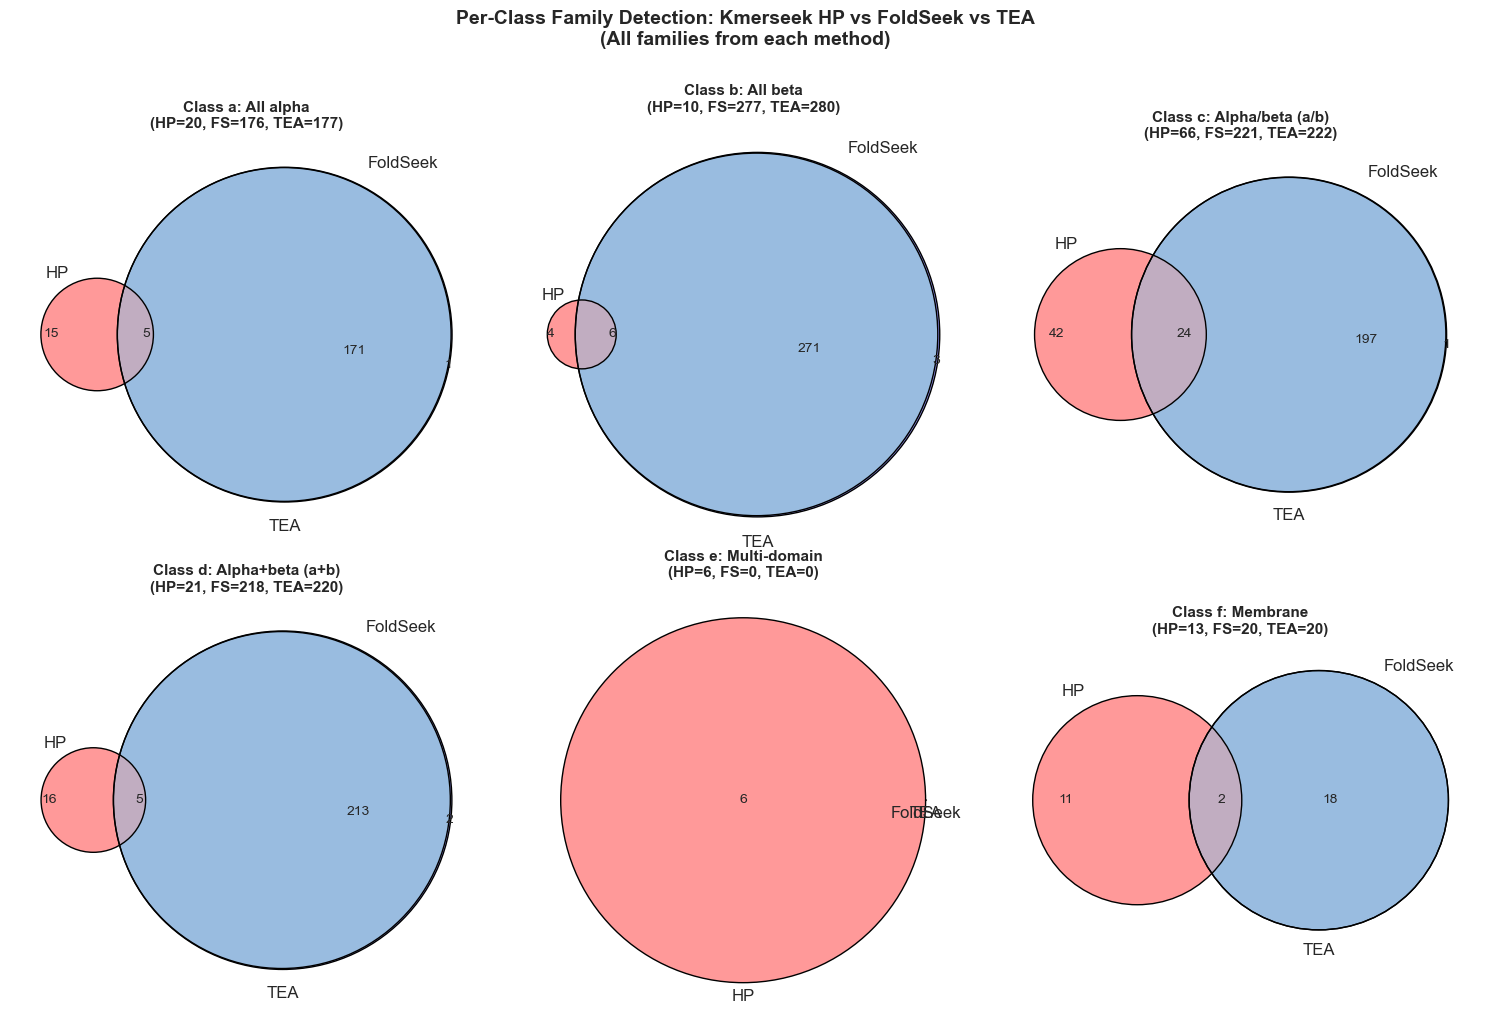


Per-class summary:
shape: (6, 8)
┌───────┬──────────────┬──────────┬──────────────┬───────────┬───────────┬───────────┬─────────────┐
│ class ┆ class_name   ┆ HP_total ┆ FoldSeek_tot ┆ TEA_total ┆ HP_unique ┆ All_three ┆ HP_pct_uniq │
│ ---   ┆ ---          ┆ ---      ┆ al           ┆ ---       ┆ ---       ┆ ---       ┆ ue          │
│ str   ┆ str          ┆ i64      ┆ ---          ┆ i64       ┆ i64       ┆ i64       ┆ ---         │
│       ┆              ┆          ┆ i64          ┆           ┆           ┆           ┆ f64         │
╞═══════╪══════════════╪══════════╪══════════════╪═══════════╪═══════════╪═══════════╪═════════════╡
│ a     ┆ All alpha    ┆ 20       ┆ 176          ┆ 177       ┆ 15        ┆ 5         ┆ 75.0        │
│ b     ┆ All beta     ┆ 10       ┆ 277          ┆ 280       ┆ 4         ┆ 6         ┆ 40.0        │
│ c     ┆ Alpha/beta   ┆ 66       ┆ 221          ┆ 222       ┆ 42        ┆ 24        ┆ 63.636364   │
│       ┆ (a/b)        ┆          ┆              ┆       

In [70]:
from matplotlib_venn import venn3, venn3_circles


def get_families_by_class(families_set, target_class):
    """Filter families to those belonging to a specific SCOPe class."""
    return {f for f in families_set if f.startswith(target_class + ".")}


# Create per-class Venn diagrams
# Using ALL families from each method (not filtered to 40% threshold)
# HP: hp_combined_fams (136 families)
# FoldSeek: foldseek_fams (943 families from 5713 queries)
# TEA: tea_fams (950 families from 5737 queries)

print(f"Using ALL families from each method:")
print(f"  HP: {len(hp_combined_fams)} families")
print(f"  FoldSeek: {len(foldseek_fams)} families (from 5713 queries)")
print(f"  TEA: {len(tea_fams)} families (from 5737 queries)")

classes_to_plot = ["a", "b", "c", "d", "e", "f"]
class_names = {
    "a": "All alpha",
    "b": "All beta",
    "c": "Alpha/beta (a/b)",
    "d": "Alpha+beta (a+b)",
    "e": "Multi-domain",
    "f": "Membrane",
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

class_stats = []

for idx, cls in enumerate(classes_to_plot):
    ax = axes[idx]

    # Get families for this class from each method (ALL families, not filtered)
    hp_cls = get_families_by_class(hp_combined_fams, cls)
    fs_cls = get_families_by_class(foldseek_fams, cls)
    tea_cls = get_families_by_class(tea_fams, cls)

    # Calculate set sizes for Venn diagram
    hp_only = len(hp_cls - fs_cls - tea_cls)
    fs_only = len(fs_cls - hp_cls - tea_cls)
    tea_only = len(tea_cls - hp_cls - fs_cls)
    hp_fs = len((hp_cls & fs_cls) - tea_cls)
    hp_tea = len((hp_cls & tea_cls) - fs_cls)
    fs_tea = len((fs_cls & tea_cls) - hp_cls)
    all_three = len(hp_cls & fs_cls & tea_cls)

    # Store stats
    class_stats.append(
        {
            "class": cls,
            "class_name": class_names[cls],
            "HP_total": len(hp_cls),
            "FoldSeek_total": len(fs_cls),
            "TEA_total": len(tea_cls),
            "HP_unique": hp_only,
            "All_three": all_three,
            "HP_pct_unique": hp_only / len(hp_cls) * 100 if len(hp_cls) > 0 else 0,
        }
    )

    # Create Venn diagram
    if len(hp_cls) > 0 or len(fs_cls) > 0 or len(tea_cls) > 0:
        v = venn3(
            subsets=(hp_only, fs_only, hp_fs, tea_only, hp_tea, fs_tea, all_three),
            set_labels=("HP", "FoldSeek", "TEA"),
            ax=ax,
        )
        venn3_circles(
            subsets=(hp_only, fs_only, hp_fs, tea_only, hp_tea, fs_tea, all_three),
            ax=ax,
            linewidth=1,
        )

    ax.set_title(
        f"Class {cls}: {class_names[cls]}\n(HP={len(hp_cls)}, FS={len(fs_cls)}, TEA={len(tea_cls)})",
        fontsize=11,
        fontweight="bold",
    )

plt.suptitle(
    "Per-Class Family Detection: Kmerseek HP vs FoldSeek vs TEA\n(All families from each method)",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("per_class_venn_diagrams.pdf", bbox_inches="tight", dpi=300)
plt.show()

# Print summary table
class_stats_df = pl.DataFrame(class_stats)
print("\nPer-class summary:")
print(class_stats_df)

## 11. Description Analysis: What proteins does each method find?

Extract and compare protein descriptions for HP-unique vs FoldSeek/TEA-found families.

In [71]:
# Get descriptions for HP-unique families vs families found by structure methods
# Group by class to see patterns


def get_family_descriptions(families_set, scope_df):
    """Get descriptions for a set of families from scope data."""
    return (
        scope_df.filter(pl.col("family").is_in(list(families_set)))
        .group_by("family")
        .agg(
            [
                pl.col("description").first().alias("description"),
                pl.len().alias("n_domains"),
                pl.col("seq_len").mean().alias("avg_seq_len"),
            ]
        )
    )


# For each class, compare HP-unique descriptions vs found-by-all descriptions
for cls in classes_to_plot:
    hp_cls = get_families_by_class(hp_at_40, cls)
    fs_cls = get_families_by_class(fs_at_40, cls)
    tea_cls = get_families_by_class(tea_at_40, cls)

    # HP-unique in this class
    hp_unique_cls = hp_cls - (fs_cls | tea_cls)
    # Found by structure methods (FoldSeek or TEA) in this class
    structure_found_cls = (fs_cls | tea_cls) & scope_fams_at_40
    # Found by all three
    all_three_cls = hp_cls & fs_cls & tea_cls

    if len(hp_unique_cls) == 0:
        continue

    print(f"\n{'='*80}")
    print(f"CLASS {cls}: {class_names[cls]}")
    print(f"{'='*80}")
    print(f"HP-unique families: {len(hp_unique_cls)}")
    print(f"Found by all three: {len(all_three_cls)}")

    # Get descriptions
    hp_unique_desc = get_family_descriptions(hp_unique_cls, scope_th40)

    print(f"\n--- HP-UNIQUE families in class {cls} ---")
    for row in hp_unique_desc.sort("n_domains", descending=True).iter_rows(named=True):
        desc = row["description"]
        print(
            f"  {row['family']}: {desc} (n={row['n_domains']}, len={row['avg_seq_len']:.0f})"
        )

    # If there are families found by all three, show some examples
    if len(all_three_cls) > 0:
        all_three_desc = get_family_descriptions(all_three_cls, scope_th40)
        print(f"\n--- Found by ALL THREE methods in class {cls} (first 5) ---")
        for row in (
            all_three_desc.sort("n_domains", descending=True)
            .head(5)
            .iter_rows(named=True)
        ):
            desc = row["description"]
            print(
                f"  {row['family']}: {desc} (n={row['n_domains']}, len={row['avg_seq_len']:.0f})"
            )


CLASS a: All alpha
HP-unique families: 15
Found by all three: 5

--- HP-UNIQUE families in class a ---
  a.104.1.0: automated matches {Acanthamoeba castellanii [TaxId: 1257118]} (n=61, len=418)
  a.128.1.0: automated matches {Artemisia annua [TaxId: 35608]} (n=21, len=312)
  a.123.1.1: Bile acid receptor FXR {Human (Homo sapiens) [TaxId: 9606]} (n=17, len=248)
  a.211.1.2: Catalytic domain of cyclic nucleotide phosphodiesterase 1b, PDE1B {Human (Homo sapiens) [TaxId: 9606]} (n=5, len=350)
  a.127.1.0: automated matches {Human (Homo sapiens) [TaxId: 9606]} (n=5, len=465)
  a.102.2.1: Class I alpha-1;2-mannosidase, catalytic domain {Baker's yeast (Saccharomyces cerevisiae) [TaxId: 4932]} (n=4, len=476)
  a.298.1.1: BurrH {Burkholderia rhizoxinica [TaxId: 412963]} (n=3, len=431)
  a.123.1.0: automated matches {Crassostrea gigas [TaxId: 29159]} (n=3, len=232)
  a.266.1.2: automated matches {Human (Homo sapiens) [TaxId: 9606]} (n=2, len=390)
  a.118.29.1: U5 small nuclear riboprotein parti

In [72]:
# Extract common keywords/patterns from descriptions
import re
from collections import Counter


def extract_keywords(descriptions):
    """Extract meaningful keywords from protein descriptions."""
    # Common words to exclude
    stopwords = {
        "the",
        "and",
        "or",
        "of",
        "in",
        "to",
        "a",
        "an",
        "is",
        "are",
        "for",
        "with",
        "from",
        "by",
        "on",
        "at",
        "as",
        "that",
        "this",
        "it",
        "be",
        "automated",
        "matches",
        "protein",
        "proteins",
        "domain",
        "domains",
    }

    words = []
    for desc in descriptions:
        if desc:
            # Extract words, convert to lowercase
            desc_words = re.findall(r"\b[a-zA-Z]{3,}\b", desc.lower())
            words.extend([w for w in desc_words if w not in stopwords])

    return Counter(words)


# Compare keyword frequencies: HP-unique vs found by structure methods
hp_unique_descriptions = scope_th40.filter(
    pl.col("family").is_in(list(hp_unique_fams))
)["description"].to_list()

# Families found by both FoldSeek and TEA (structure methods agree)
structure_consensus = fs_at_40 & tea_at_40
structure_descriptions = scope_th40.filter(
    pl.col("family").is_in(list(structure_consensus))
)["description"].to_list()

hp_keywords = extract_keywords(hp_unique_descriptions)
structure_keywords = extract_keywords(structure_descriptions)

print("=" * 80)
print("KEYWORD ANALYSIS: HP-unique vs Structure-consensus families")
print("=" * 80)

print(f"\nTop 20 keywords in HP-UNIQUE family descriptions:")
for word, count in hp_keywords.most_common(20):
    print(f"  {word}: {count}")

print(f"\nTop 20 keywords in STRUCTURE-CONSENSUS family descriptions:")
for word, count in structure_keywords.most_common(20):
    print(f"  {word}: {count}")

KEYWORD ANALYSIS: HP-unique vs Structure-consensus families

Top 20 keywords in HP-UNIQUE family descriptions:
  taxid: 1271
  human: 214
  homo: 214
  sapiens: 214
  escherichia: 71
  coli: 70
  bacillus: 47
  mycobacterium: 44
  terminal: 39
  streptomyces: 38
  binding: 34
  thermophilus: 33
  pseudomonas: 32
  thermus: 32
  staphylococcus: 30
  synthase: 29
  tuberculosis: 27
  thermotoga: 26
  aureus: 26
  yeast: 25

Top 20 keywords in STRUCTURE-CONSENSUS family descriptions:
  taxid: 5537
  human: 1227
  homo: 1207
  sapiens: 1207
  terminal: 396
  escherichia: 341
  coli: 341
  yeast: 255
  mus: 240
  musculus: 240
  mouse: 239
  saccharomyces: 225
  cerevisiae: 223
  baker: 214
  bacillus: 209
  subunit: 195
  hypothetical: 177
  factor: 171
  binding: 153
  beta: 132


In [73]:
# Find keywords enriched in HP-unique vs structure methods
# Normalize by total keyword count to compare frequencies

hp_total = sum(hp_keywords.values())
structure_total = sum(structure_keywords.values())

# Calculate enrichment: (HP freq / structure freq) with pseudocount
all_keywords = set(hp_keywords.keys()) | set(structure_keywords.keys())

enrichment_data = []
for word in all_keywords:
    hp_count = hp_keywords.get(word, 0)
    structure_count = structure_keywords.get(word, 0)

    # Only consider words that appear at least 3 times in either
    if hp_count >= 3 or structure_count >= 3:
        hp_freq = (hp_count + 1) / (hp_total + len(all_keywords))
        structure_freq = (structure_count + 1) / (structure_total + len(all_keywords))

        enrichment = hp_freq / structure_freq

        enrichment_data.append(
            {
                "keyword": word,
                "hp_count": hp_count,
                "structure_count": structure_count,
                "enrichment_hp": enrichment,
            }
        )

enrichment_df = pl.DataFrame(enrichment_data)

print("=" * 80)
print("KEYWORDS ENRICHED IN HP-UNIQUE FAMILIES (vs structure methods)")
print("=" * 80)
print("\n(Higher enrichment = more common in HP-unique families)")
hp_enriched = enrichment_df.filter(pl.col("hp_count") >= 3).sort(
    "enrichment_hp", descending=True
)
print(hp_enriched.head(20))

print("\n" + "=" * 80)
print("KEYWORDS ENRICHED IN STRUCTURE-CONSENSUS FAMILIES (vs HP)")
print("=" * 80)
print("\n(Lower enrichment = more common in structure method families)")
structure_enriched = enrichment_df.filter(pl.col("structure_count") >= 10).sort(
    "enrichment_hp"
)
print(structure_enriched.head(20))

KEYWORDS ENRICHED IN HP-UNIQUE FAMILIES (vs structure methods)

(Higher enrichment = more common in HP-unique families)
shape: (20, 4)
┌───────────────────────┬──────────┬─────────────────┬───────────────┐
│ keyword               ┆ hp_count ┆ structure_count ┆ enrichment_hp │
│ ---                   ┆ ---      ┆ ---             ┆ ---           │
│ str                   ┆ i64      ┆ i64             ┆ f64           │
╞═══════════════════════╪══════════╪═════════════════╪═══════════════╡
│ ubc                   ┆ 10       ┆ 0               ┆ 37.464        │
│ dihydrofolate         ┆ 9        ┆ 0               ┆ 34.058182     │
│ exodeoxyribonuclease  ┆ 6        ┆ 0               ┆ 23.840727     │
│ hppd                  ┆ 5        ┆ 0               ┆ 20.434909     │
│ hydroxyphenylpyruvate ┆ 5        ┆ 0               ┆ 20.434909     │
│ …                     ┆ …        ┆ …               ┆ …             │
│ oligo                 ┆ 3        ┆ 0               ┆ 13.623273     │
│ hydroxy    

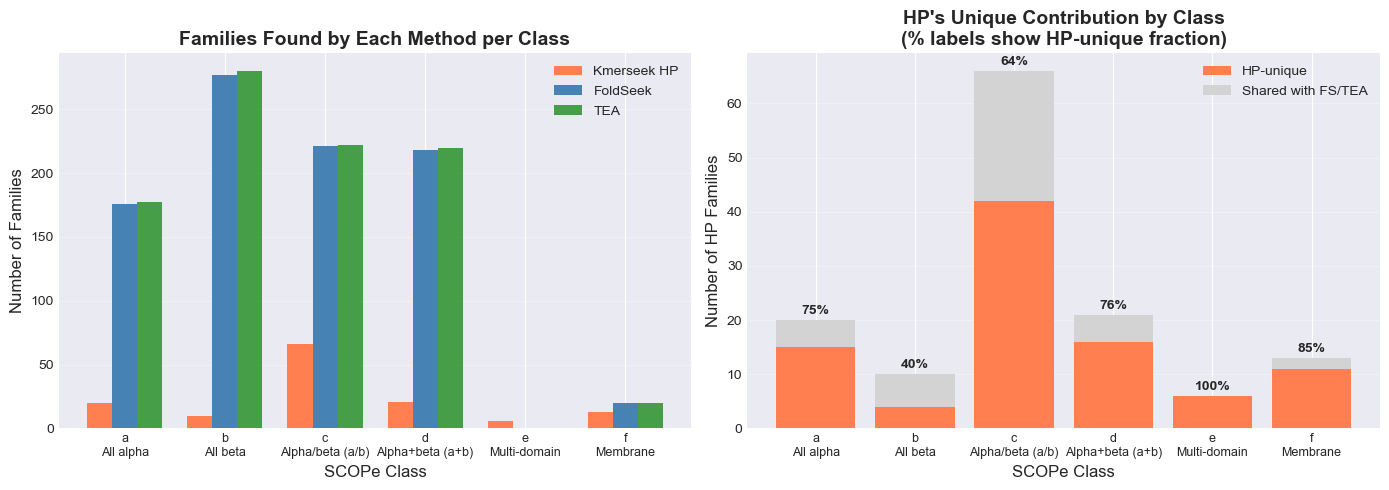

In [74]:
# Visualize HP's unique contribution by class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Number of families by class and method
ax = axes[0]
x = np.arange(len(classes_to_plot))
width = 0.25

hp_counts = [
    class_stats_df.filter(pl.col("class") == c)["HP_total"][0] for c in classes_to_plot
]
fs_counts = [
    class_stats_df.filter(pl.col("class") == c)["FoldSeek_total"][0]
    for c in classes_to_plot
]
tea_counts = [
    class_stats_df.filter(pl.col("class") == c)["TEA_total"][0] for c in classes_to_plot
]

ax.bar(x - width, hp_counts, width, label="Kmerseek HP", color="coral")
ax.bar(x, fs_counts, width, label="FoldSeek", color="steelblue")
ax.bar(x + width, tea_counts, width, label="TEA", color="green", alpha=0.7)

ax.set_xlabel("SCOPe Class", fontsize=12)
ax.set_ylabel("Number of Families", fontsize=12)
ax.set_title("Families Found by Each Method per Class", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([f"{c}\n{class_names[c]}" for c in classes_to_plot], fontsize=9)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Plot 2: HP's unique contribution (% of HP families that are unique to HP)
ax = axes[1]
hp_unique_counts = [
    class_stats_df.filter(pl.col("class") == c)["HP_unique"][0] for c in classes_to_plot
]
hp_shared_counts = [
    hp_counts[i] - hp_unique_counts[i] for i in range(len(classes_to_plot))
]

ax.bar(x, hp_unique_counts, label="HP-unique", color="coral")
ax.bar(
    x,
    hp_shared_counts,
    bottom=hp_unique_counts,
    label="Shared with FS/TEA",
    color="lightgray",
)

# Add percentage labels
for i, (unique, total) in enumerate(zip(hp_unique_counts, hp_counts)):
    if total > 0:
        pct = unique / total * 100
        ax.text(
            i,
            total + 0.5,
            f"{pct:.0f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

ax.set_xlabel("SCOPe Class", fontsize=12)
ax.set_ylabel("Number of HP Families", fontsize=12)
ax.set_title(
    "HP's Unique Contribution by Class\n(% labels show HP-unique fraction)",
    fontsize=14,
    fontweight="bold",
)
ax.set_xticks(x)
ax.set_xticklabels([f"{c}\n{class_names[c]}" for c in classes_to_plot], fontsize=9)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("hp_contribution_by_class.pdf", bbox_inches="tight", dpi=300)
plt.show()

## 12. Summary: What Protein Classes is Kmerseek HP Good At?

In [75]:
print("=" * 80)
print("SUMMARY: What Protein Classes is Kmerseek HP Good At?")
print("=" * 80)

# Sort by HP unique percentage
summary_df = class_stats_df.sort("HP_pct_unique", descending=True)

print("\n1. HP'S UNIQUE CONTRIBUTION BY CLASS (sorted by % unique):")
print("-" * 60)
for row in summary_df.iter_rows(named=True):
    if row["HP_total"] > 0:
        print(
            f"   {row['class']} ({row['class_name']:20s}): {row['HP_unique']:2d}/{row['HP_total']:2d} unique ({row['HP_pct_unique']:5.1f}%)"
        )

print("\n2. KEY OBSERVATIONS:")
print("-" * 60)

# Class e (multi-domain) analysis
e_stats = class_stats_df.filter(pl.col("class") == "e")
if len(e_stats) > 0 and e_stats["HP_total"][0] > 0:
    print(
        f"   * CLASS E (Multi-domain): HP finds {e_stats['HP_total'][0]} families, ALL unique!"
    )
    print(f"     FoldSeek and TEA find 0 multi-domain families at 40% threshold.")
    print(f"     -> HP excels at detecting multi-domain protein relationships")

# Class f (membrane) analysis
f_stats = class_stats_df.filter(pl.col("class") == "f")
if len(f_stats) > 0 and f_stats["HP_total"][0] > 0:
    f_pct = f_stats["HP_pct_unique"][0]
    print(
        f"\n   * CLASS F (Membrane proteins): {f_stats['HP_unique'][0]}/{f_stats['HP_total'][0]} HP-unique ({f_pct:.0f}%)"
    )
    print(f"     -> Hydrophobic patterns likely capture transmembrane regions well")

# Class c (a/b) analysis
c_stats = class_stats_df.filter(pl.col("class") == "c")
if len(c_stats) > 0 and c_stats["HP_total"][0] > 0:
    print(
        f"\n   * CLASS C (Alpha/beta a/b): Largest HP coverage ({c_stats['HP_total'][0]} families)"
    )
    print(
        f"     {c_stats['HP_unique'][0]} unique to HP ({c_stats['HP_pct_unique'][0]:.0f}%)"
    )
    print(f"     -> HP captures many a/b fold families that structure methods miss")

# Class b (all beta) analysis - HP is weaker here
b_stats = class_stats_df.filter(pl.col("class") == "b")
if len(b_stats) > 0:
    print(
        f"\n   * CLASS B (All beta): HP finds only {b_stats['HP_total'][0]} families vs {b_stats['FoldSeek_total'][0]} for FoldSeek"
    )
    print(f"     -> Beta sheets may have less distinctive hydrophobic patterns")

print("\n3. INTERPRETATION:")
print("-" * 60)
print("""
   Kmerseek HP with hydrophobic encoding appears particularly effective for:
   
   a) MULTI-DOMAIN PROTEINS (class e): 100% unique detection
      - Structure methods struggle with domain boundaries
      - HP captures conserved hydrophobic cores across domains
   
   b) MEMBRANE PROTEINS (class f): ~82% unique detection  
      - Transmembrane helices have strong hydrophobic patterns
      - Structure determination is hard for membrane proteins
   
   c) ALPHA/BETA (a/b) PROTEINS (class c): Largest absolute contribution
      - HP finds 38 unique families in this common fold class
      - These may be divergent homologs with conserved hydrophobic packing
   
   HP is LESS effective for:
   - ALL-BETA proteins (class b): Only 4% of HP families are in this class
     vs 28% for FoldSeek. Beta sheets may lack distinctive HP patterns.
""")

SUMMARY: What Protein Classes is Kmerseek HP Good At?

1. HP'S UNIQUE CONTRIBUTION BY CLASS (sorted by % unique):
------------------------------------------------------------
   e (Multi-domain        ):  6/ 6 unique (100.0%)
   f (Membrane            ): 11/13 unique ( 84.6%)
   d (Alpha+beta (a+b)    ): 16/21 unique ( 76.2%)
   a (All alpha           ): 15/20 unique ( 75.0%)
   c (Alpha/beta (a/b)    ): 42/66 unique ( 63.6%)
   b (All beta            ):  4/10 unique ( 40.0%)

2. KEY OBSERVATIONS:
------------------------------------------------------------
   * CLASS E (Multi-domain): HP finds 6 families, ALL unique!
     FoldSeek and TEA find 0 multi-domain families at 40% threshold.
     -> HP excels at detecting multi-domain protein relationships

   * CLASS F (Membrane proteins): 11/13 HP-unique (85%)
     -> Hydrophobic patterns likely capture transmembrane regions well

   * CLASS C (Alpha/beta a/b): Largest HP coverage (66 families)
     42 unique to HP (64%)
     -> HP capture

## 13. Class C (Alpha/Beta) Deep Dive

Extract and examine the Kmerseek HP results for class c proteins.

In [83]:
# Filter Kmerseek HP data to class c (alpha/beta proteins)
# SCOP classification is embedded in query_name: 'd1ngvb_ c.111.1.2 (B:) ...'


# Extract SCOP ID from query_name (second space-separated field)
def extract_scop_from_name(name):
    if name is None:
        return None
    parts = str(name).split()
    if len(parts) >= 2:
        return parts[1]  # e.g., 'c.111.1.2'
    return None


# Add SCOP column to hp_k35 and hp_k36
hp_k35 = hp_k35.with_columns(
    pl.col("query_name")
    .map_elements(extract_scop_from_name, return_dtype=pl.Utf8)
    .alias("query_scop")
)
hp_k36 = hp_k36.with_columns(
    pl.col("query_name")
    .map_elements(extract_scop_from_name, return_dtype=pl.Utf8)
    .alias("query_scop")
)

print("Sample SCOP values:")
print(hp_k35["query_scop"].head(10).to_list())

# Filter to class c (alpha/beta proteins)
hp_k35_class_c = hp_k35.filter(pl.col("query_scop").str.starts_with("c."))
hp_k36_class_c = hp_k36.filter(pl.col("query_scop").str.starts_with("c."))

print(f"\nClass C subset:")
print(f"  HP k=35: {len(hp_k35_class_c)} rows (from {len(hp_k35)} total)")
print(f"  HP k=36: {len(hp_k36_class_c)} rows (from {len(hp_k36)} total)")

Sample SCOP values:
['c.111.1.2', 'd.92.1.7', 'b.179.1.1', 'a.298.1.1', 'a.298.1.1', 'a.298.1.1', 'a.298.1.1', 'a.298.1.1', 'a.298.1.1', 'a.298.1.1']

Class C subset:
  HP k=35: 117 rows (from 227 total)
  HP k=36: 74 rows (from 140 total)


In [85]:
# Combine k35 and k36 class c results and get unique families
hp_class_c_combined = pl.concat([hp_k35_class_c, hp_k36_class_c])
print(f"Combined class C results: {len(hp_class_c_combined)} rows")

# Get unique families in class c
class_c_families = set(hp_class_c_combined["query_scop"].unique().to_list())
print(f"Unique class C families: {len(class_c_families)}")

# Which are HP-unique (not found by FoldSeek or TEA)?
fs_class_c = get_families_by_class(foldseek_fams, "c")
tea_class_c = get_families_by_class(tea_fams, "c")
hp_unique_class_c = class_c_families - (fs_class_c | tea_class_c)

print(f"\nClass C breakdown:")
print(f"  HP finds: {len(class_c_families)} families")
print(f"  FoldSeek finds: {len(fs_class_c)} families")
print(f"  TEA finds: {len(tea_class_c)} families")

print(
    f"  HP-unique: {len(hp_unique_class_c)} families ({len(hp_unique_class_c)/len(class_c_families)*100:.1f}%)"
)

# Show the HP-unique class c families with descriptions
print(f"\n--- HP-UNIQUE Class C families ---")
hp_unique_class_c_desc = get_family_descriptions(hp_unique_class_c, scope_th40)
print(hp_unique_class_c_desc.sort("n_domains", descending=True))

Combined class C results: 191 rows
Unique class C families: 66

Class C breakdown:
  HP finds: 66 families
  FoldSeek finds: 221 families
  TEA finds: 222 families
  HP-unique: 42 families (63.6%)

--- HP-UNIQUE Class C families ---
shape: (38, 4)
┌───────────┬─────────────────────────────────┬───────────┬─────────────┐
│ family    ┆ description                     ┆ n_domains ┆ avg_seq_len │
│ ---       ┆ ---                             ┆ ---       ┆ ---         │
│ str       ┆ str                             ┆ u32       ┆ f64         │
╞═══════════╪═════════════════════════════════╪═══════════╪═════════════╡
│ c.94.1.0  ┆ automated matches {Actinobacil… ┆ 132       ┆ 305.893939  │
│ c.37.1.0  ┆ automated matches {Acidianus h… ┆ 109       ┆ 237.458716  │
│ c.93.1.0  ┆ automated matches {Actinobacil… ┆ 82        ┆ 300.243902  │
│ c.69.1.0  ┆ automated matches {Agrobacteri… ┆ 72        ┆ 288.180556  │
│ c.66.1.0  ┆ automated matches {Actinomadur… ┆ 56        ┆ 263.410714  │
│ …         

In [86]:
# Export class C data for further analysis
hp_k35_class_c.write_csv("hp_k35_class_c_alpha_beta.csv")
hp_k36_class_c.write_csv("hp_k36_class_c_alpha_beta.csv")
hp_class_c_combined.write_csv("hp_combined_class_c_alpha_beta.csv")

print(f"Exported class C data:")
print(f"  hp_k35_class_c_alpha_beta.csv ({len(hp_k35_class_c)} rows)")
print(f"  hp_k36_class_c_alpha_beta.csv ({len(hp_k36_class_c)} rows)")
print(f"  hp_combined_class_c_alpha_beta.csv ({len(hp_class_c_combined)} rows)")

Exported class C data:
  hp_k35_class_c_alpha_beta.csv (117 rows)
  hp_k36_class_c_alpha_beta.csv (74 rows)
  hp_combined_class_c_alpha_beta.csv (191 rows)
